In [ ]:
from pybm.examples.predator_prey import  generate_synthetic_data
import torch


true_const_values = {
    "growth_rate_prey": 0.5,
    "growth_rate_predator": -0.2,
    "predation_rate": 0.02,
    "conversion_efficiency": 0.1
}

# Generate model and data from /home/urhp/Documents/PyBM/src/pybm/examples/predator_prey.py
model, components, times = generate_synthetic_data()
model.engine = "torch"
print(str(model))
# send to torch 
for var_name, var in model.vars.items():
    if var.data is not None:
        var.data.to_torch()
# change times to a torch tensor
t_eval = torch.tensor(times)
# reshape into (1, n_times)
#t_eval = torch.reshape(t_eval, (1, -1))

# print initial values of the variables
print("Initial values of the variables:")
for var_name, var in model.vars.items():
    print(f"{var_name}: {var.initial}")  

# set initial values of the constants to bad guesses
model.consts["growth_rate_prey"].initial_value = 0.1 #0.5
model.consts["growth_rate_predator"].initial_value = 0.1 #-0.2
model.consts["predation_rate"].initial_value = 0.1 #0.02
model.consts["conversion_efficiency"].initial_value = 0.1 #0.1



# print initial values of the constants
print("\nInitial values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {const.initial_value}")


Model(Entities: [],
 Vars: ['n_prey', 'n_predator', 'temperature'],
 Consts: ['growth_rate_prey', 'growth_rate_predator', 'predation_rate', 'conversion_efficiency'])
Initial values of the variables:
n_prey: 40.000492061342996
n_predator: 8.016754323781468
temperature: None

Initial values of the constants:
growth_rate_prey: 0.5
growth_rate_predator: -0.2
predation_rate: 0.05
conversion_efficiency: 0.05


In [2]:
from pybm.estimate.gradient_matching import estimate_gradient_matching
from pybm.estimate.multishooting_torch import estimate_torch

# estimate the parameters using gradient matching (fast, but less accurate)
# to get a good initial guess for the parameters
result = estimate_gradient_matching(model, t_eval)
init_params = result.init_params(n_subintervals=10)
init_consts = result.consts
print("\n Initial guesses, collected from gradient matching:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {init_consts[const.index_in_ctx]} (real value: {true_const_values[const_name]})")



 Initial guesses, collected from gradient matching:
growth_rate_prey: 0.4995117555895066 (real value: 0.5)
growth_rate_predator: -0.19993410872528397 (real value: -0.2)
predation_rate: 0.019927213658000167 (real value: 0.02)
conversion_efficiency: 0.10004850500224169 (real value: 0.1)


In [3]:


# estimate the parameters using multishooting (slower, but more accurate)
fit = estimate_torch(model, t_eval, method="weighted_sum",
                      n_subintervals=10, n_candidates=1,
                      init_params=init_params, verbose=2, n_iter=500, maxiter=500)
const_values_torch = fit.consts

[weighted_sum     0] A=1 B=1e-08 traj_res(min/mean)=4269/4269 cont_res(min/mean)=12.92/12.92


/home/urhp/Documents/PyBM/src/pybm/utils.py:11: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  inds = torch.searchsorted(xp, x)


[weighted_sum    10] A=1 B=1.661e-08 traj_res(min/mean)=1.945e+05/1.945e+05 cont_res(min/mean)=1860/1860
[weighted_sum    20] A=1 B=2.76e-08 traj_res(min/mean)=2.584e+05/2.584e+05 cont_res(min/mean)=2067/2067
[weighted_sum    30] A=1 B=4.585e-08 traj_res(min/mean)=1.795e+05/1.795e+05 cont_res(min/mean)=1067/1067
[weighted_sum    40] A=1 B=7.617e-08 traj_res(min/mean)=8.675e+04/8.675e+04 cont_res(min/mean)=343.2/343.2
[weighted_sum    50] A=1 B=1.265e-07 traj_res(min/mean)=3.788e+04/3.788e+04 cont_res(min/mean)=146.5/146.5
[weighted_sum    60] A=1 B=2.102e-07 traj_res(min/mean)=1.27e+04/1.27e+04 cont_res(min/mean)=126.1/126.1
[weighted_sum    70] A=1 B=3.492e-07 traj_res(min/mean)=9494/9494 cont_res(min/mean)=150.9/150.9
[weighted_sum    80] A=1 B=5.801e-07 traj_res(min/mean)=4957/4957 cont_res(min/mean)=25.44/25.44
[weighted_sum    90] A=1 B=9.638e-07 traj_res(min/mean)=4491/4491 cont_res(min/mean)=13.97/13.97
[weighted_sum   100] A=1 B=1.601e-06 traj_res(min/mean)=4088/4088 cont_res(m

In [4]:


# update model constants with estimated values
for const_name, const in model.consts.items():
    const.initial_value = const_values_torch[const.index_in_ctx].item()

print("\nEstimated values of the constants:")
for const_name, const in model.consts.items():
    print(f"{const_name}: {round(const.initial_value, 2)}, true value: {true_const_values[const_name]}")


Estimated values of the constants:
growth_rate_prey: 0.51, true value: 0.5
growth_rate_predator: -0.3, true value: -0.2
predation_rate: 0.03, true value: 0.02
conversion_efficiency: 0.06, true value: 0.1


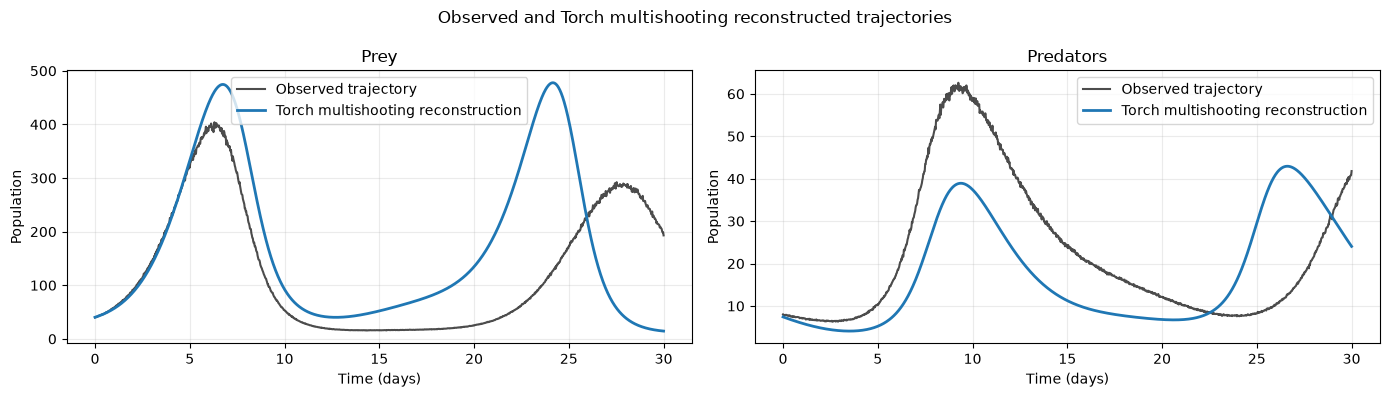

In [6]:
import importlib
import matplotlib.pyplot as plt
import pybm.estimate.multishooting_torch as multishooting_torch_module

multishooting_torch_module = importlib.reload(multishooting_torch_module)
simulate_multishooting_torch = multishooting_torch_module.simulate_multishooting

# Reconstruct the fitted multishooting trajectory from the full parameter vector.
fitted_solution = simulate_multishooting_torch(
    model,
    t_eval,
    params=fit.x,
    n_subintervals=1,
 )

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

series = [
    ("n_prey", "Prey"),
    ("n_predator", "Predators"),
]

for index, (name, title) in enumerate(series):
    ax = axes[index]
    observed = components[name].data.x

    ax.plot(
        times, observed,
        label="Observed trajectory",
        color="black",
        alpha=0.7,
    )
    ax.plot(
        times, fitted_solution.y[index],
        label="Torch multishooting reconstruction",
        color="tab:blue",
        linewidth=2,
    )

    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Observed and Torch multishooting reconstructed trajectories")
fig.tight_layout()
plt.show()